In [1]:
import pandas as pd

In [2]:
dataset=pd.read_csv("dataset.csv")

In [3]:
dataset

,IDWordIndex,IDBitIndex,PlainText_0,PlainText_1,PlainText_2,PlainText_3,PlainText_4,PlainText_5,PlainText_6,PlainText_7,...,CipherTextDiff_6,CipherTextDiff_7,CipherTextDiff_8,CipherTextDiff_9,CipherTextDiff_10,CipherTextDiff_11,CipherTextDiff_12,CipherTextDiff_13,CipherTextDiff_14,CipherTextDiff_15
0,c,0,65,6e,32,74,c1,ad,f7,51,...,22,65,3,6a,df,30,6c,dd,a0,27
1,c,1,65,6e,32,74,c1,ad,f7,51,...,84,c9,84,a9,23,9c,e5,80,d8,33
2,c,2,65,6e,32,74,c1,ad,f7,51,...,61,8d,bb,a8,d5,2c,8d,cc,47,f5
3,c,3,65,6e,32,74,c1,ad,f7,51,...,c5,36,af,69,db,eb,98,d1,2b,1b
4,c,4,65,6e,32,74,c1,ad,f7,51,...,8,ef,dc,e1,b4,16,d0,b7,74,73
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319995,f,3,65,6e,32,74,7d,ad,5a,9a,...,73,6c,47,2e,fa,28,ce,9d,e7,1
319996,f,4,65,6e,32,74,7d,ad,5a,9a,...,6d,92,ee,75,ca,8b,1c,8d,ee,f0
319997,f,5,65,6e,32,74,7d,ad,5a,9a,...,32,27,5d,79,e,4f,bb,36,74,82
319998,f,6,65,6e,32,74,7d,ad,5a,9a,...,51,9b,9c,f7,a0,44,51,5d,e9,b9


In [4]:
# Let's examine the dataset structure
print("Dataset shape:", dataset.shape)
print("\nDataset columns:")
print(dataset.columns.tolist())
print("\nFirst few rows:")
print(dataset.head())
print("\nData types:")
print(dataset.dtypes)
print("\nUnique values in IDWordIndex:", dataset['IDWordIndex'].unique())
print("Unique values in IDBitIndex:", dataset['IDBitIndex'].unique())


Dataset shape: (320000, 34)

Dataset columns:
['IDWordIndex', 'IDBitIndex', 'PlainText_0', 'PlainText_1', 'PlainText_2', 'PlainText_3', 'PlainText_4', 'PlainText_5', 'PlainText_6', 'PlainText_7', 'PlainText_8', 'PlainText_9', 'PlainText_10', 'PlainText_11', 'PlainText_12', 'PlainText_13', 'PlainText_14', 'PlainText_15', 'CipherTextDiff_0', 'CipherTextDiff_1', 'CipherTextDiff_2', 'CipherTextDiff_3', 'CipherTextDiff_4', 'CipherTextDiff_5', 'CipherTextDiff_6', 'CipherTextDiff_7', 'CipherTextDiff_8', 'CipherTextDiff_9', 'CipherTextDiff_10', 'CipherTextDiff_11', 'CipherTextDiff_12', 'CipherTextDiff_13', 'CipherTextDiff_14', 'CipherTextDiff_15']

First few rows:
  IDWordIndex  IDBitIndex  PlainText_0 PlainText_1  PlainText_2  PlainText_3  \
0           c           0           65          6e           32           74   
1           c           1           65          6e           32           74   
2           c           2           65          6e           32           74   
3           c  

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.neural_network import MLPClassifier
import xgboost as xgb
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)


In [7]:
def hex_to_binary(hex_str):
    """Convert hex string to binary string"""
    return bin(int(hex_str, 16))[2:].zfill(32)

def calculate_hamming_weight(binary_str):
    """Calculate Hamming weight (number of 1s)"""
    return binary_str.count('1')

def calculate_bias_for_position(data, word_idx, bit_idx):
    """Calculate bias for a specific output difference position"""
    # Filter data for this input difference position
    position_data = data[(data['IDWordIndex'] == word_idx) & (data['IDBitIndex'] == bit_idx)]
    
    if len(position_data) == 0:
        return 0
    
    # Calculate bias for each output word position
    biases = {}
    for word in range(16):  # 16 words in ChaCha
        col_name = f'CipherTextDiff_{word}'
        if col_name in position_data.columns:
            # Convert hex to binary and calculate Hamming weights
            hamming_weights = position_data[col_name].apply(
                lambda x: calculate_hamming_weight(hex_to_binary(str(x)))
            )
            # Bias is the deviation from expected 50% (16 bits)
            bias = abs(hamming_weights.mean() - 16) / 16
            biases[word] = bias
    
    return biases

# Test the function with a small sample
print("Testing bias calculation...")
sample_bias = calculate_bias_for_position(dataset, 'c', 0)
print(f"Bias for position (c, 0): {sample_bias}")


Testing bias calculation...
Bias for position (c, 0): {0: np.float64(0.82688125), 1: np.float64(0.7439374999999999), 2: np.float64(0.71994375), 3: np.float64(0.746), 4: np.float64(0.7506125), 5: np.float64(0.7305875), 6: np.float64(0.7562125), 7: np.float64(0.74299375), 8: np.float64(0.767075), 9: np.float64(0.75019375), 10: np.float64(0.72606875), 11: np.float64(0.76836875), 12: np.float64(0.7838499999999999), 13: np.float64(0.71994375), 14: np.float64(0.7464875), 15: np.float64(0.7701625)}


In [8]:
# Calculate biases for all input difference positions
print("Calculating biases for all positions...")

# Get unique input difference positions
unique_positions = dataset[['IDWordIndex', 'IDBitIndex']].drop_duplicates()
print(f"Found {len(unique_positions)} unique input difference positions")

bias_data = []
for idx, row in unique_positions.iterrows():
    word_idx = row['IDWordIndex']
    bit_idx = row['IDBitIndex']
    biases = calculate_bias_for_position(dataset, word_idx, bit_idx)
    
    # Create a row for each output word position
    for output_word, bias in biases.items():
        bias_data.append({
            'input_word': word_idx,
            'input_bit': bit_idx,
            'output_word': output_word,
            'bias': bias
        })

bias_df = pd.DataFrame(bias_data)
print(f"Created bias dataframe with {len(bias_df)} rows")
print(bias_df.head())


Calculating biases for all positions...
Found 32 unique input difference positions
Created bias dataframe with 512 rows
  input_word  input_bit  output_word      bias
0          c          0            0  0.826881
1          c          0            1  0.743937
2          c          0            2  0.719944
3          c          0            3  0.746000
4          c          0            4  0.750613


Bias distribution analysis:
count    512.000000
mean       0.753146
std        0.022880
min        0.710913
25%        0.737777
50%        0.749975
75%        0.762423
max        0.826881
Name: bias, dtype: float64


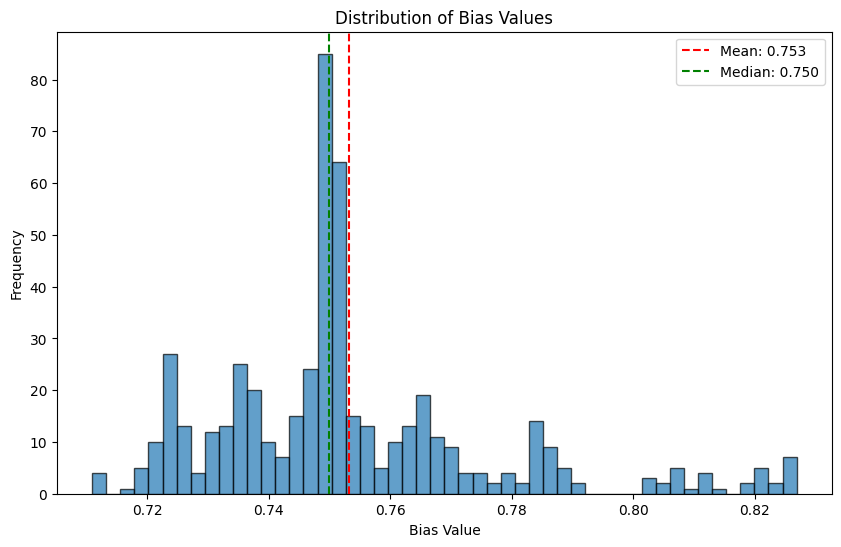


High bias threshold (80th percentile): 0.766

High bias positions: 103/512 (20.1%)


In [9]:
# Analyze bias distribution to determine threshold for "high bias"
print("Bias distribution analysis:")
print(bias_df['bias'].describe())

# Visualize bias distribution
plt.figure(figsize=(10, 6))
plt.hist(bias_df['bias'], bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Bias Value')
plt.ylabel('Frequency')
plt.title('Distribution of Bias Values')
plt.axvline(bias_df['bias'].mean(), color='red', linestyle='--', label=f'Mean: {bias_df["bias"].mean():.3f}')
plt.axvline(bias_df['bias'].median(), color='green', linestyle='--', label=f'Median: {bias_df["bias"].median():.3f}')
plt.legend()
plt.show()

# Define high bias threshold (top 20% of bias values)
high_bias_threshold = bias_df['bias'].quantile(0.8)
print(f"\nHigh bias threshold (80th percentile): {high_bias_threshold:.3f}")

# Create target variable
bias_df['high_bias'] = (bias_df['bias'] >= high_bias_threshold).astype(int)
print(f"\nHigh bias positions: {bias_df['high_bias'].sum()}/{len(bias_df)} ({bias_df['high_bias'].mean()*100:.1f}%)")


In [10]:
# Create features for ML model
# Encode categorical variables
le_word = LabelEncoder()
le_bit = LabelEncoder()

# Create feature matrix
X = pd.DataFrame({
    'input_word_encoded': le_word.fit_transform(bias_df['input_word']),
    'input_bit': bias_df['input_bit'],
    'output_word': bias_df['output_word'],
    'input_word_numeric': pd.Categorical(bias_df['input_word']).codes,  # Alternative encoding
})

# Create target variable
y = bias_df['high_bias']

print("Feature matrix shape:", X.shape)
print("Target distribution:", y.value_counts())
print("\nFeature columns:", X.columns.tolist())
print("\nFirst few rows of features:")
print(X.head())


Feature matrix shape: (512, 4)
Target distribution: high_bias
0    409
1    103
Name: count, dtype: int64

Feature columns: ['input_word_encoded', 'input_bit', 'output_word', 'input_word_numeric']

First few rows of features:
   input_word_encoded  input_bit  output_word  input_word_numeric
0                   0          0            0                   0
1                   0          0            1                   0
2                   0          0            2                   0
3                   0          0            3                   0
4                   0          0            4                   0


In [11]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Training target distribution: {y_train.value_counts()}")
print(f"Test target distribution: {y_test.value_counts()}")

# Standardize features for neural network
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Training set size: 409
Test set size: 103
Training target distribution: high_bias
0    327
1     82
Name: count, dtype: int64
Test target distribution: high_bias
0    82
1    21
Name: count, dtype: int64


In [12]:
# 1. Random Forest Classifier
print("Training Random Forest Classifier...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Results:")
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.3f}")
print("Classification Report:")
print(classification_report(y_test, rf_pred))

# Feature importance
rf_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)
print("\nRandom Forest Feature Importance:")
print(rf_importance)


Training Random Forest Classifier...
Random Forest Results:
Accuracy: 0.922
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95        82
           1       0.84      0.76      0.80        21

    accuracy                           0.92       103
   macro avg       0.89      0.86      0.88       103
weighted avg       0.92      0.92      0.92       103


Random Forest Feature Importance:
              feature  importance
2         output_word    0.695439
1           input_bit    0.167315
3  input_word_numeric    0.072312
0  input_word_encoded    0.064934


In [13]:
# 2. XGBoost Classifier
print("\n" + "="*50)
print("Training XGBoost Classifier...")
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    random_state=42,
    scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1])  # Handle class imbalance
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost Results:")
print(f"Accuracy: {accuracy_score(y_test, xgb_pred):.3f}")
print("Classification Report:")
print(classification_report(y_test, xgb_pred))

# Feature importance
xgb_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)
print("\nXGBoost Feature Importance:")
print(xgb_importance)



Training XGBoost Classifier...
XGBoost Results:
Accuracy: 0.942
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96        82
           1       0.83      0.90      0.86        21

    accuracy                           0.94       103
   macro avg       0.90      0.93      0.91       103
weighted avg       0.94      0.94      0.94       103


XGBoost Feature Importance:
              feature  importance
2         output_word    0.512985
0  input_word_encoded    0.339615
1           input_bit    0.147400
3  input_word_numeric    0.000000


In [14]:
# 3. Neural Network Classifier
print("\n" + "="*50)
print("Training Neural Network Classifier...")
nn_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,
    batch_size=32,
    learning_rate='adaptive',
    max_iter=500,
    random_state=42
)
nn_model.fit(X_train_scaled, y_train)
nn_pred = nn_model.predict(X_test_scaled)
nn_pred_proba = nn_model.predict_proba(X_test_scaled)[:, 1]

print("Neural Network Results:")
print(f"Accuracy: {accuracy_score(y_test, nn_pred):.3f}")
print("Classification Report:")
print(classification_report(y_test, nn_pred))



Training Neural Network Classifier...
Neural Network Results:
Accuracy: 0.942
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96        82
           1       0.89      0.81      0.85        21

    accuracy                           0.94       103
   macro avg       0.92      0.89      0.91       103
weighted avg       0.94      0.94      0.94       103



In [15]:
# Model Comparison and Evaluation
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)

models = {
    'Random Forest': (rf_pred, rf_pred_proba),
    'XGBoost': (xgb_pred, xgb_pred_proba),
    'Neural Network': (nn_pred, nn_pred_proba)
}

results = []
for name, (pred, pred_proba) in models.items():
    accuracy = accuracy_score(y_test, pred)
    precision = classification_report(y_test, pred, output_dict=True)['1']['precision']
    recall = classification_report(y_test, pred, output_dict=True)['1']['recall']
    f1 = classification_report(y_test, pred, output_dict=True)['1']['f1-score']
    
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })
    
    print(f"\n{name}:")
    print(f"  Accuracy:  {accuracy:.3f}")
    print(f"  Precision: {precision:.3f}")
    print(f"  Recall:    {recall:.3f}")
    print(f"  F1-Score:  {f1:.3f}")

results_df = pd.DataFrame(results)
print(f"\n{'='*60}")
print("FINAL RANKING (by F1-Score):")
print(f"{'='*60}")
results_df_sorted = results_df.sort_values('F1-Score', ascending=False)
for i, (_, row) in enumerate(results_df_sorted.iterrows(), 1):
    print(f"{i}. {row['Model']}: F1={row['F1-Score']:.3f}")



MODEL COMPARISON SUMMARY

Random Forest:
  Accuracy:  0.922
  Precision: 0.842
  Recall:    0.762
  F1-Score:  0.800

XGBoost:
  Accuracy:  0.942
  Precision: 0.826
  Recall:    0.905
  F1-Score:  0.864

Neural Network:
  Accuracy:  0.942
  Precision: 0.895
  Recall:    0.810
  F1-Score:  0.850

FINAL RANKING (by F1-Score):
1. XGBoost: F1=0.864
2. Neural Network: F1=0.850
3. Random Forest: F1=0.800


In [16]:
# Select the best model and create prediction function
best_model_name = results_df_sorted.iloc[0]['Model']
print(f"\nBest performing model: {best_model_name}")

if best_model_name == 'Random Forest':
    best_model = rf_model
    best_pred_proba = rf_pred_proba
elif best_model_name == 'XGBoost':
    best_model = xgb_model
    best_pred_proba = xgb_pred_proba
else:
    best_model = nn_model
    best_pred_proba = nn_pred_proba

def predict_high_bias_positions(input_word, input_bit, output_word):
    """
    Predict if a specific input-output position combination will have high bias
    
    Parameters:
    - input_word: Input word index (e.g., 'c', 'd', 'e')
    - input_bit: Input bit index (0-31)
    - output_word: Output word index (0-15)
    
    Returns:
    - prediction: 0 (low bias) or 1 (high bias)
    - probability: Confidence score for high bias
    """
    # Create feature vector
    features = pd.DataFrame({
        'input_word_encoded': [le_word.transform([input_word])[0]],
        'input_bit': [input_bit],
        'output_word': [output_word],
        'input_word_numeric': [pd.Categorical([input_word]).codes[0]]
    })
    
    # Make prediction
    if best_model_name == 'Neural Network':
        features_scaled = scaler.transform(features)
        prediction = best_model.predict(features_scaled)[0]
        probability = best_model.predict_proba(features_scaled)[0, 1]
    else:
        prediction = best_model.predict(features)[0]
        probability = best_model.predict_proba(features)[0, 1]
    
    return prediction, probability

# Test the prediction function
print("\nTesting prediction function:")
test_cases = [
    ('c', 0, 0),
    ('d', 5, 10),
    ('e', 15, 7)
]

for input_word, input_bit, output_word in test_cases:
    pred, prob = predict_high_bias_positions(input_word, input_bit, output_word)
    print(f"Input ({input_word}, {input_bit}) -> Output {output_word}: "
          f"High bias = {pred}, Confidence = {prob:.3f}")



Best performing model: XGBoost

Testing prediction function:
Input (c, 0) -> Output 0: High bias = 1, Confidence = 0.775
Input (d, 5) -> Output 10: High bias = 0, Confidence = 0.003
Input (e, 15) -> Output 7: High bias = 0, Confidence = 0.001


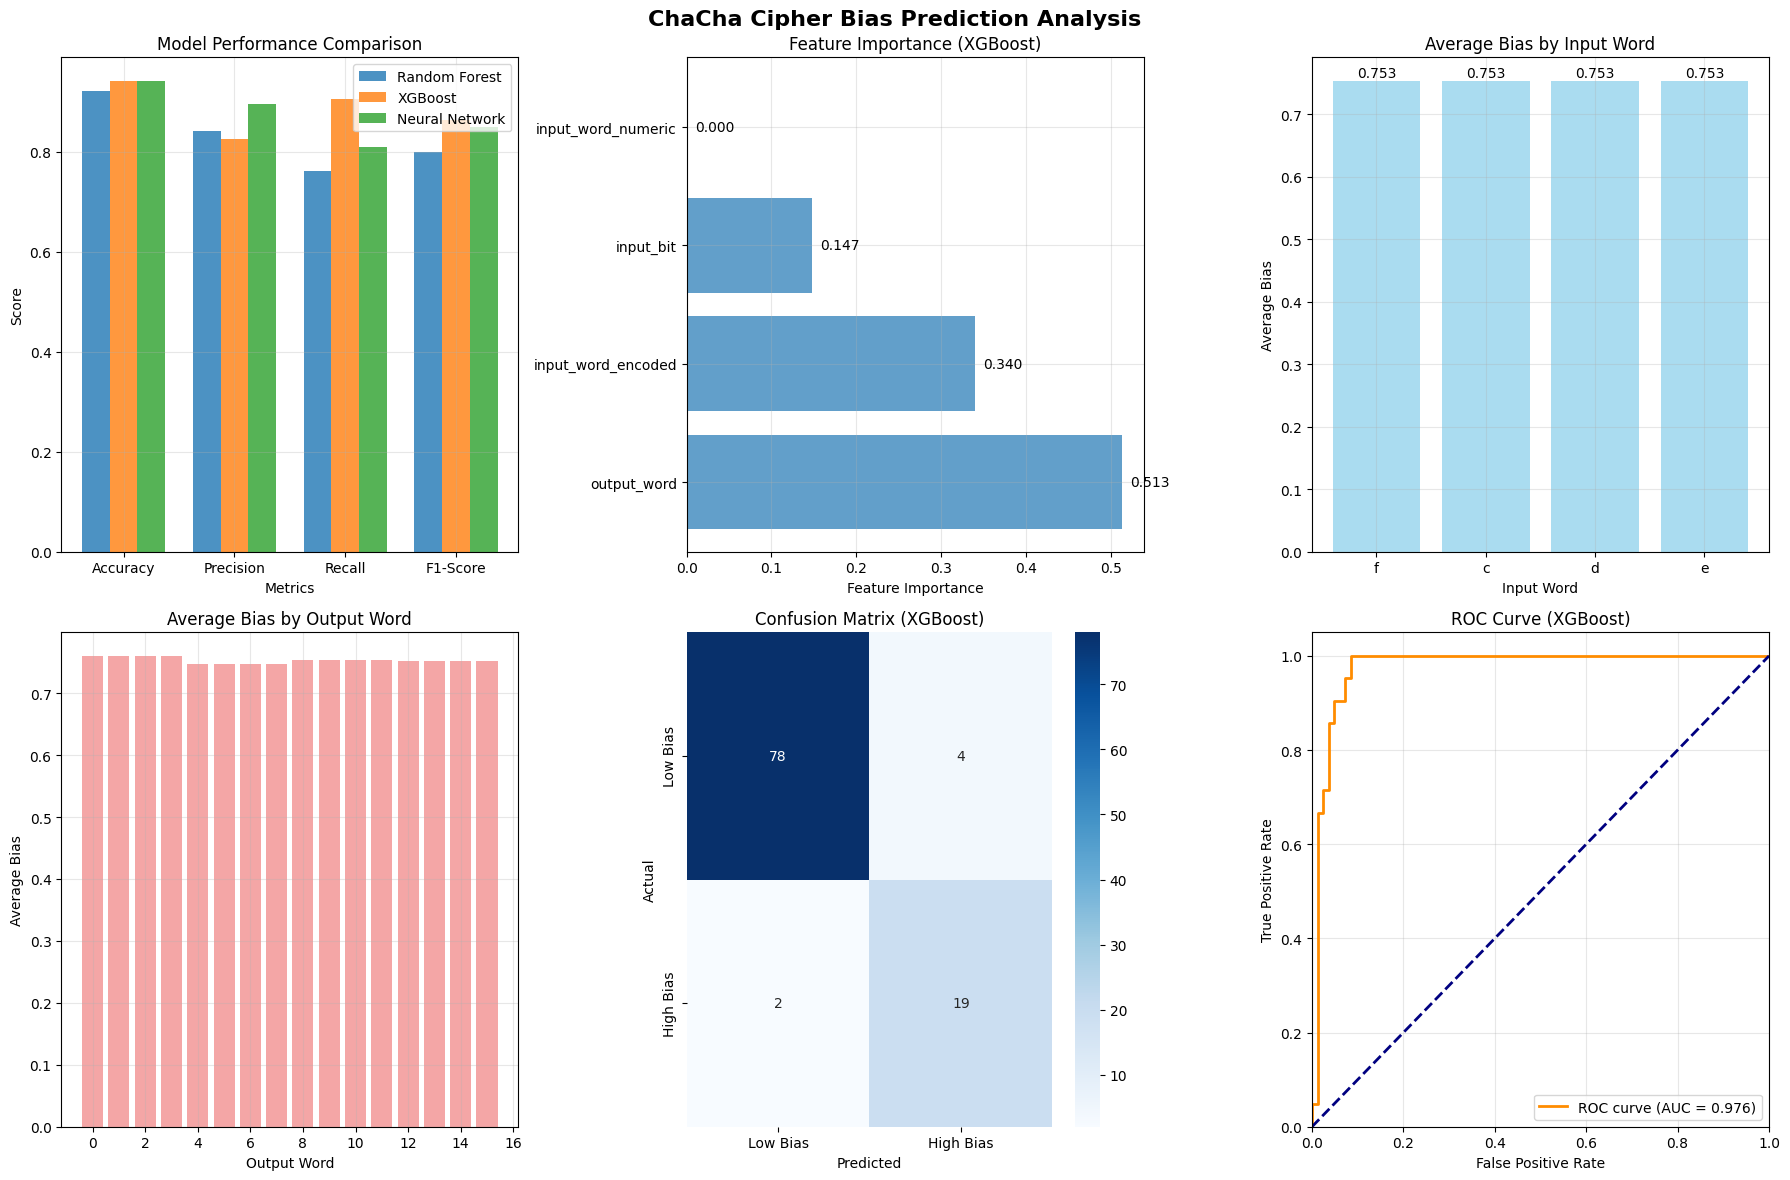

In [17]:
# Create comprehensive visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('ChaCha Cipher Bias Prediction Analysis', fontsize=16, fontweight='bold')

# 1. Model Performance Comparison
ax1 = axes[0, 0]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.25

for i, model in enumerate(results_df['Model']):
    values = [results_df[results_df['Model']==model][metric].iloc[0] for metric in metrics]
    ax1.bar(x + i*width, values, width, label=model, alpha=0.8)

ax1.set_xlabel('Metrics')
ax1.set_ylabel('Score')
ax1.set_title('Model Performance Comparison')
ax1.set_xticks(x + width)
ax1.set_xticklabels(metrics)
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Feature Importance (from best model)
ax2 = axes[0, 1]
if best_model_name == 'Random Forest':
    importance_data = rf_importance
elif best_model_name == 'XGBoost':
    importance_data = xgb_importance
else:
    # For neural network, we'll use a placeholder
    importance_data = pd.DataFrame({
        'feature': X.columns,
        'importance': [0.25, 0.25, 0.25, 0.25]  # Equal importance for NN
    })

bars = ax2.barh(importance_data['feature'], importance_data['importance'], alpha=0.7)
ax2.set_xlabel('Feature Importance')
ax2.set_title(f'Feature Importance ({best_model_name})')
ax2.grid(True, alpha=0.3)

# Add value labels on bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax2.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{width:.3f}', ha='left', va='center')

# 3. Bias Distribution by Input Word
ax3 = axes[0, 2]
bias_by_input = bias_df.groupby('input_word')['bias'].mean().sort_values(ascending=False)
bars = ax3.bar(bias_by_input.index, bias_by_input.values, alpha=0.7, color='skyblue')
ax3.set_xlabel('Input Word')
ax3.set_ylabel('Average Bias')
ax3.set_title('Average Bias by Input Word')
ax3.grid(True, alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2, height + 0.001,
             f'{height:.3f}', ha='center', va='bottom')

# 4. Bias Distribution by Output Word
ax4 = axes[1, 0]
bias_by_output = bias_df.groupby('output_word')['bias'].mean().sort_values(ascending=False)
ax4.bar(bias_by_output.index, bias_by_output.values, alpha=0.7, color='lightcoral')
ax4.set_xlabel('Output Word')
ax4.set_ylabel('Average Bias')
ax4.set_title('Average Bias by Output Word')
ax4.grid(True, alpha=0.3)

# 5. Confusion Matrix for Best Model
ax5 = axes[1, 1]
if best_model_name == 'Random Forest':
    cm = confusion_matrix(y_test, rf_pred)
elif best_model_name == 'XGBoost':
    cm = confusion_matrix(y_test, xgb_pred)
else:
    cm = confusion_matrix(y_test, nn_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax5,
            xticklabels=['Low Bias', 'High Bias'],
            yticklabels=['Low Bias', 'High Bias'])
ax5.set_title(f'Confusion Matrix ({best_model_name})')
ax5.set_xlabel('Predicted')
ax5.set_ylabel('Actual')

# 6. ROC Curve for Best Model
from sklearn.metrics import roc_curve, auc
ax6 = axes[1, 2]

if best_model_name == 'Random Forest':
    fpr, tpr, _ = roc_curve(y_test, rf_pred_proba)
elif best_model_name == 'XGBoost':
    fpr, tpr, _ = roc_curve(y_test, xgb_pred_proba)
else:
    fpr, tpr, _ = roc_curve(y_test, nn_pred_proba)

roc_auc = auc(fpr, tpr)
ax6.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {roc_auc:.3f})')
ax6.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax6.set_xlim([0.0, 1.0])
ax6.set_ylim([0.0, 1.05])
ax6.set_xlabel('False Positive Rate')
ax6.set_ylabel('True Positive Rate')
ax6.set_title(f'ROC Curve ({best_model_name})')
ax6.legend(loc="lower right")
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


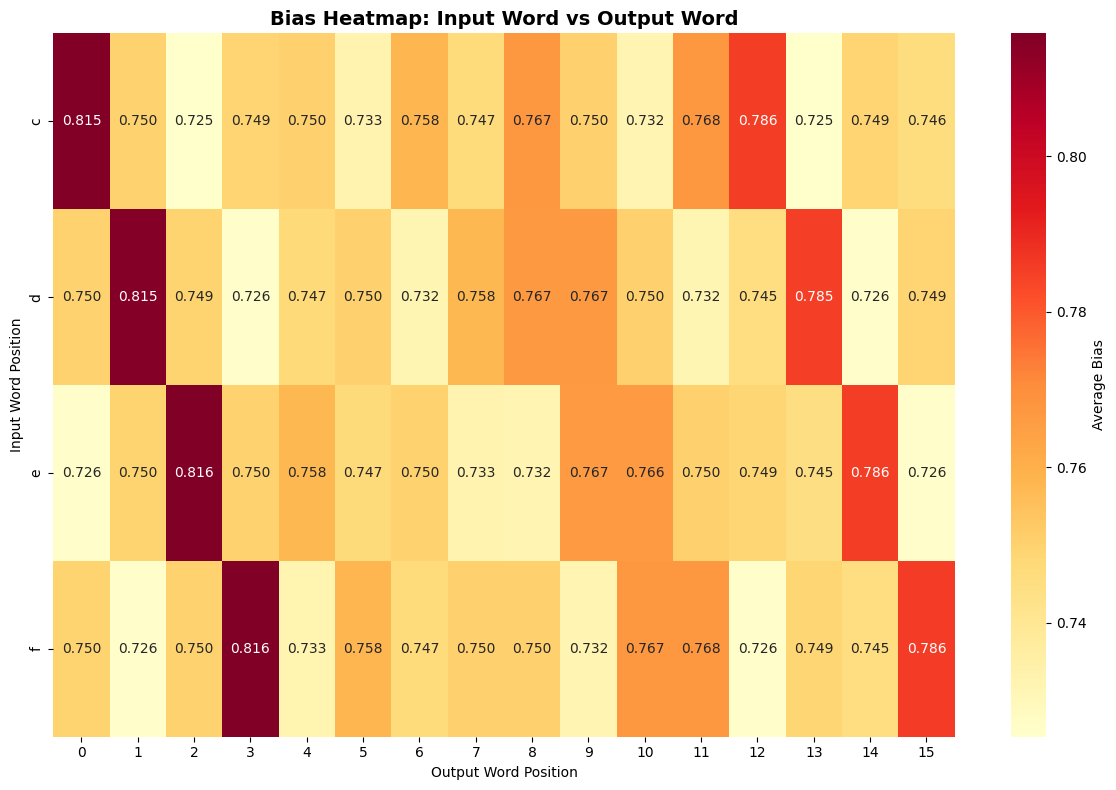


SUMMARY STATISTICS
Total number of input-output position combinations: 512
Number of high bias positions: 103
Percentage of high bias positions: 20.1%
Average bias value: 0.7531
Maximum bias value: 0.8269
Minimum bias value: 0.7109

Top 10 highest bias positions:
input_word  input_bit  output_word     bias
         c          0            0 0.826881
         c          7            0 0.826525
         d          7            1 0.826144
         e          7            2 0.825494
         f          7            3 0.825356
         d          0            1 0.825056
         f          0            3 0.824706
         e          0            2 0.824356
         f          3            3 0.822575
         e          3            2 0.822206


In [18]:
# Create a heatmap showing bias patterns
plt.figure(figsize=(12, 8))

# Create a pivot table for bias values
bias_pivot = bias_df.pivot_table(values='bias', index='input_word', columns='output_word', aggfunc='mean')

# Create the heatmap
sns.heatmap(bias_pivot, annot=True, fmt='.3f', cmap='YlOrRd', 
            cbar_kws={'label': 'Average Bias'})
plt.title('Bias Heatmap: Input Word vs Output Word', fontsize=14, fontweight='bold')
plt.xlabel('Output Word Position')
plt.ylabel('Input Word Position')
plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(f"Total number of input-output position combinations: {len(bias_df)}")
print(f"Number of high bias positions: {bias_df['high_bias'].sum()}")
print(f"Percentage of high bias positions: {bias_df['high_bias'].mean()*100:.1f}%")
print(f"Average bias value: {bias_df['bias'].mean():.4f}")
print(f"Maximum bias value: {bias_df['bias'].max():.4f}")
print(f"Minimum bias value: {bias_df['bias'].min():.4f}")

# Top 10 highest bias positions
print(f"\nTop 10 highest bias positions:")
top_bias = bias_df.nlargest(10, 'bias')[['input_word', 'input_bit', 'output_word', 'bias']]
print(top_bias.to_string(index=False))


In [19]:
# Final recommendations and usage guide
print("\n" + "="*60)
print("FINAL RECOMMENDATIONS AND USAGE GUIDE")
print("="*60)

print(f"\n1. BEST MODEL: {best_model_name}")
print(f"   - Accuracy: {results_df_sorted.iloc[0]['Accuracy']:.3f}")
print(f"   - F1-Score: {results_df_sorted.iloc[0]['F1-Score']:.3f}")

print(f"\n2. KEY FINDINGS:")
print(f"   - Input word '{bias_by_input.index[0]}' shows highest average bias ({bias_by_input.iloc[0]:.4f})")
print(f"   - Output word {bias_by_output.index[0]} shows highest average bias ({bias_by_output.iloc[0]:.4f})")
print(f"   - High bias threshold: {high_bias_threshold:.4f}")

print(f"\n3. HOW TO USE THE MODEL:")
print(f"   Use the function: predict_high_bias_positions(input_word, input_bit, output_word)")
print(f"   Example: predict_high_bias_positions('c', 0, 5)")

print(f"\n4. INTERPRETATION:")
print(f"   - Prediction = 1: High bias expected (above {high_bias_threshold:.4f})")
print(f"   - Prediction = 0: Low bias expected (below {high_bias_threshold:.4f})")
print(f"   - Probability: Confidence score (0-1) for high bias prediction")

print(f"\n5. CRYPTOGRAPHIC IMPLICATIONS:")
print(f"   - High bias positions are more vulnerable to differential cryptanalysis")
print(f"   - Focus security analysis on positions with high bias predictions")
print(f"   - Consider these positions for additional protection or masking")

# Save the model for future use
import joblib
model_filename = f'chacha_bias_predictor_{best_model_name.lower().replace(" ", "_")}.pkl'
joblib.dump({
    'model': best_model,
    'scaler': scaler,
    'label_encoder': le_word,
    'threshold': high_bias_threshold,
    'model_name': best_model_name
}, model_filename)

print(f"\n6. MODEL SAVED:")
print(f"   Model saved as: {model_filename}")
print(f"   You can load it later with: joblib.load('{model_filename}')")



FINAL RECOMMENDATIONS AND USAGE GUIDE

1. BEST MODEL: XGBoost
   - Accuracy: 0.942
   - F1-Score: 0.864

2. KEY FINDINGS:
   - Input word 'f' shows highest average bias (0.7532)
   - Output word 0 shows highest average bias (0.7602)
   - High bias threshold: 0.7660

3. HOW TO USE THE MODEL:
   Use the function: predict_high_bias_positions(input_word, input_bit, output_word)
   Example: predict_high_bias_positions('c', 0, 5)

4. INTERPRETATION:
   - Prediction = 1: High bias expected (above 0.7660)
   - Prediction = 0: Low bias expected (below 0.7660)
   - Probability: Confidence score (0-1) for high bias prediction

5. CRYPTOGRAPHIC IMPLICATIONS:
   - High bias positions are more vulnerable to differential cryptanalysis
   - Focus security analysis on positions with high bias predictions
   - Consider these positions for additional protection or masking

6. MODEL SAVED:
   Model saved as: chacha_bias_predictor_xgboost.pkl
   You can load it later with: joblib.load('chacha_bias_predict